# (24) new code: (16, 1.0)

**Motivation**: host = ```chewie```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from base.utils_model import load_model
from figures.analysis import plot_convergence
from figures.imgs import plot_weights

device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## ICLR code: Poisson + vH16

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16-wht', model_type, 'ngd|lin')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 1/16 * t_train

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

154500

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.1 K   |
|     ———     |    ———     |
|    layer    |  132.1 K   |
+-------------+------------+

poisson_vH16-wht_t-16_b-1_k-512_<ngd|lin>
b200-ep300-lr(0.001)_temp(0.05:0.5)_gr(200)_(2025_05_24,21:40)

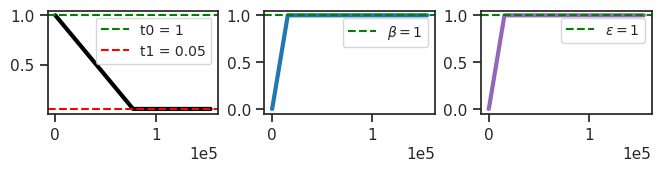

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151, 151,
        151, 151], device='cuda:1', dtype=torch.int32)

In [7]:
model.cfg.track_stats

True

In [8]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 'n_ch': 32, 't_train': 16, 'kl_beta': 1.0, 'n_latents': 512, 
'enc_type': 'ngd', 'dec_type': 'lin', 'dataset': 'vH16-wht', 'dataset_name': 'vH16-wht', 'feeder': 'stationary', 
'feeder_cfg': {}, 'input_sz': (1, 16, 16), 'shape': (-1, 1, 16, 16), 'clamp_vals': {'u': 8.0, 'du': 10.0, 'dec': 
3.45}, 'init_dist': 'normal', 'init_scale': 0.0001, 'recon_mode': 'mse', 'stochastic': True, 'fit_dec_var': False, 
'fit_prior': True, 'seed': 0, 'track_stats': True, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_vH16-wht_t-16_b-1_k-512_<ngd|lin>',
'mods_dir': '/home/hadi/Projects/PoissonVAE/models/poisson_vH16-wht_t-16_b-1_k-512_<ngd|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.001, 'epochs': 300, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 298.5, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'method': 'mc', 'kl_beta_min': 0.0001, 'kl_balancer': None,
'kl_time_adjuster': None, 'kl_anneal_cycles': 0, 'kl_anneal_portion': 0.1, 'kl_const_portion': 0.001, 
'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 0.05}

In [9]:
print(tr.model.layer.dec)

None

### Fit model

In [10]:
tr.train('NewGold')

Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

epoch # 300, avg loss: 67.261: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [2:09:16<00:00, 25.85s/it]


**Task:** reproduce this while gradually updating the code

**Conclusion:** 

In [12]:
print(model.layer.n_exp)

tensor([ 65,  96, 125, 134, 135, 134, 134, 133, 131, 131, 130, 129, 129, 128,
        127, 127], device='cuda:1', dtype=torch.int32)

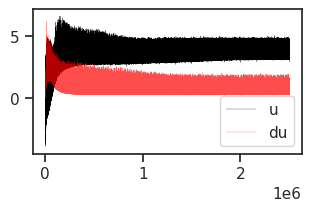

In [13]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

100%|███████████████████████████████████| 2/2 [00:03<00:00,  1.77s/it]


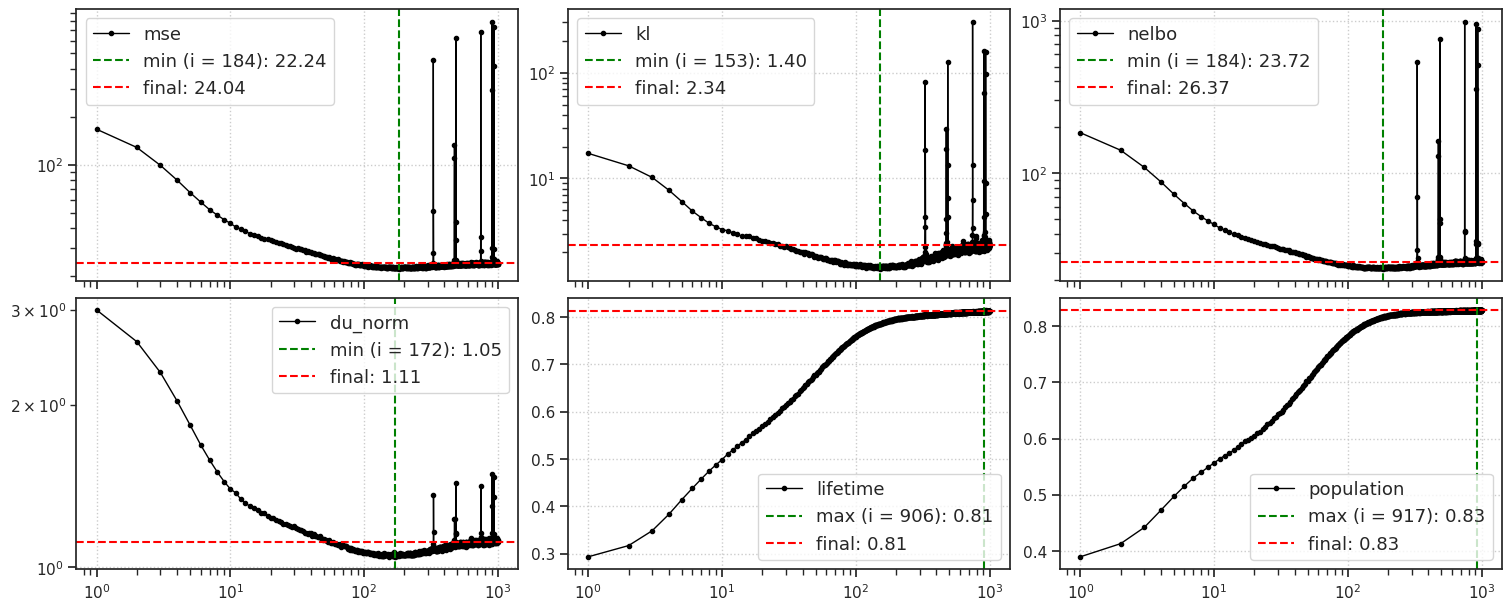

CPU times: user 5.63 s, sys: 272 ms, total: 5.9 s
Wall time: 6.08 s


In [14]:
%%time

kws = dict(
    seq_total=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

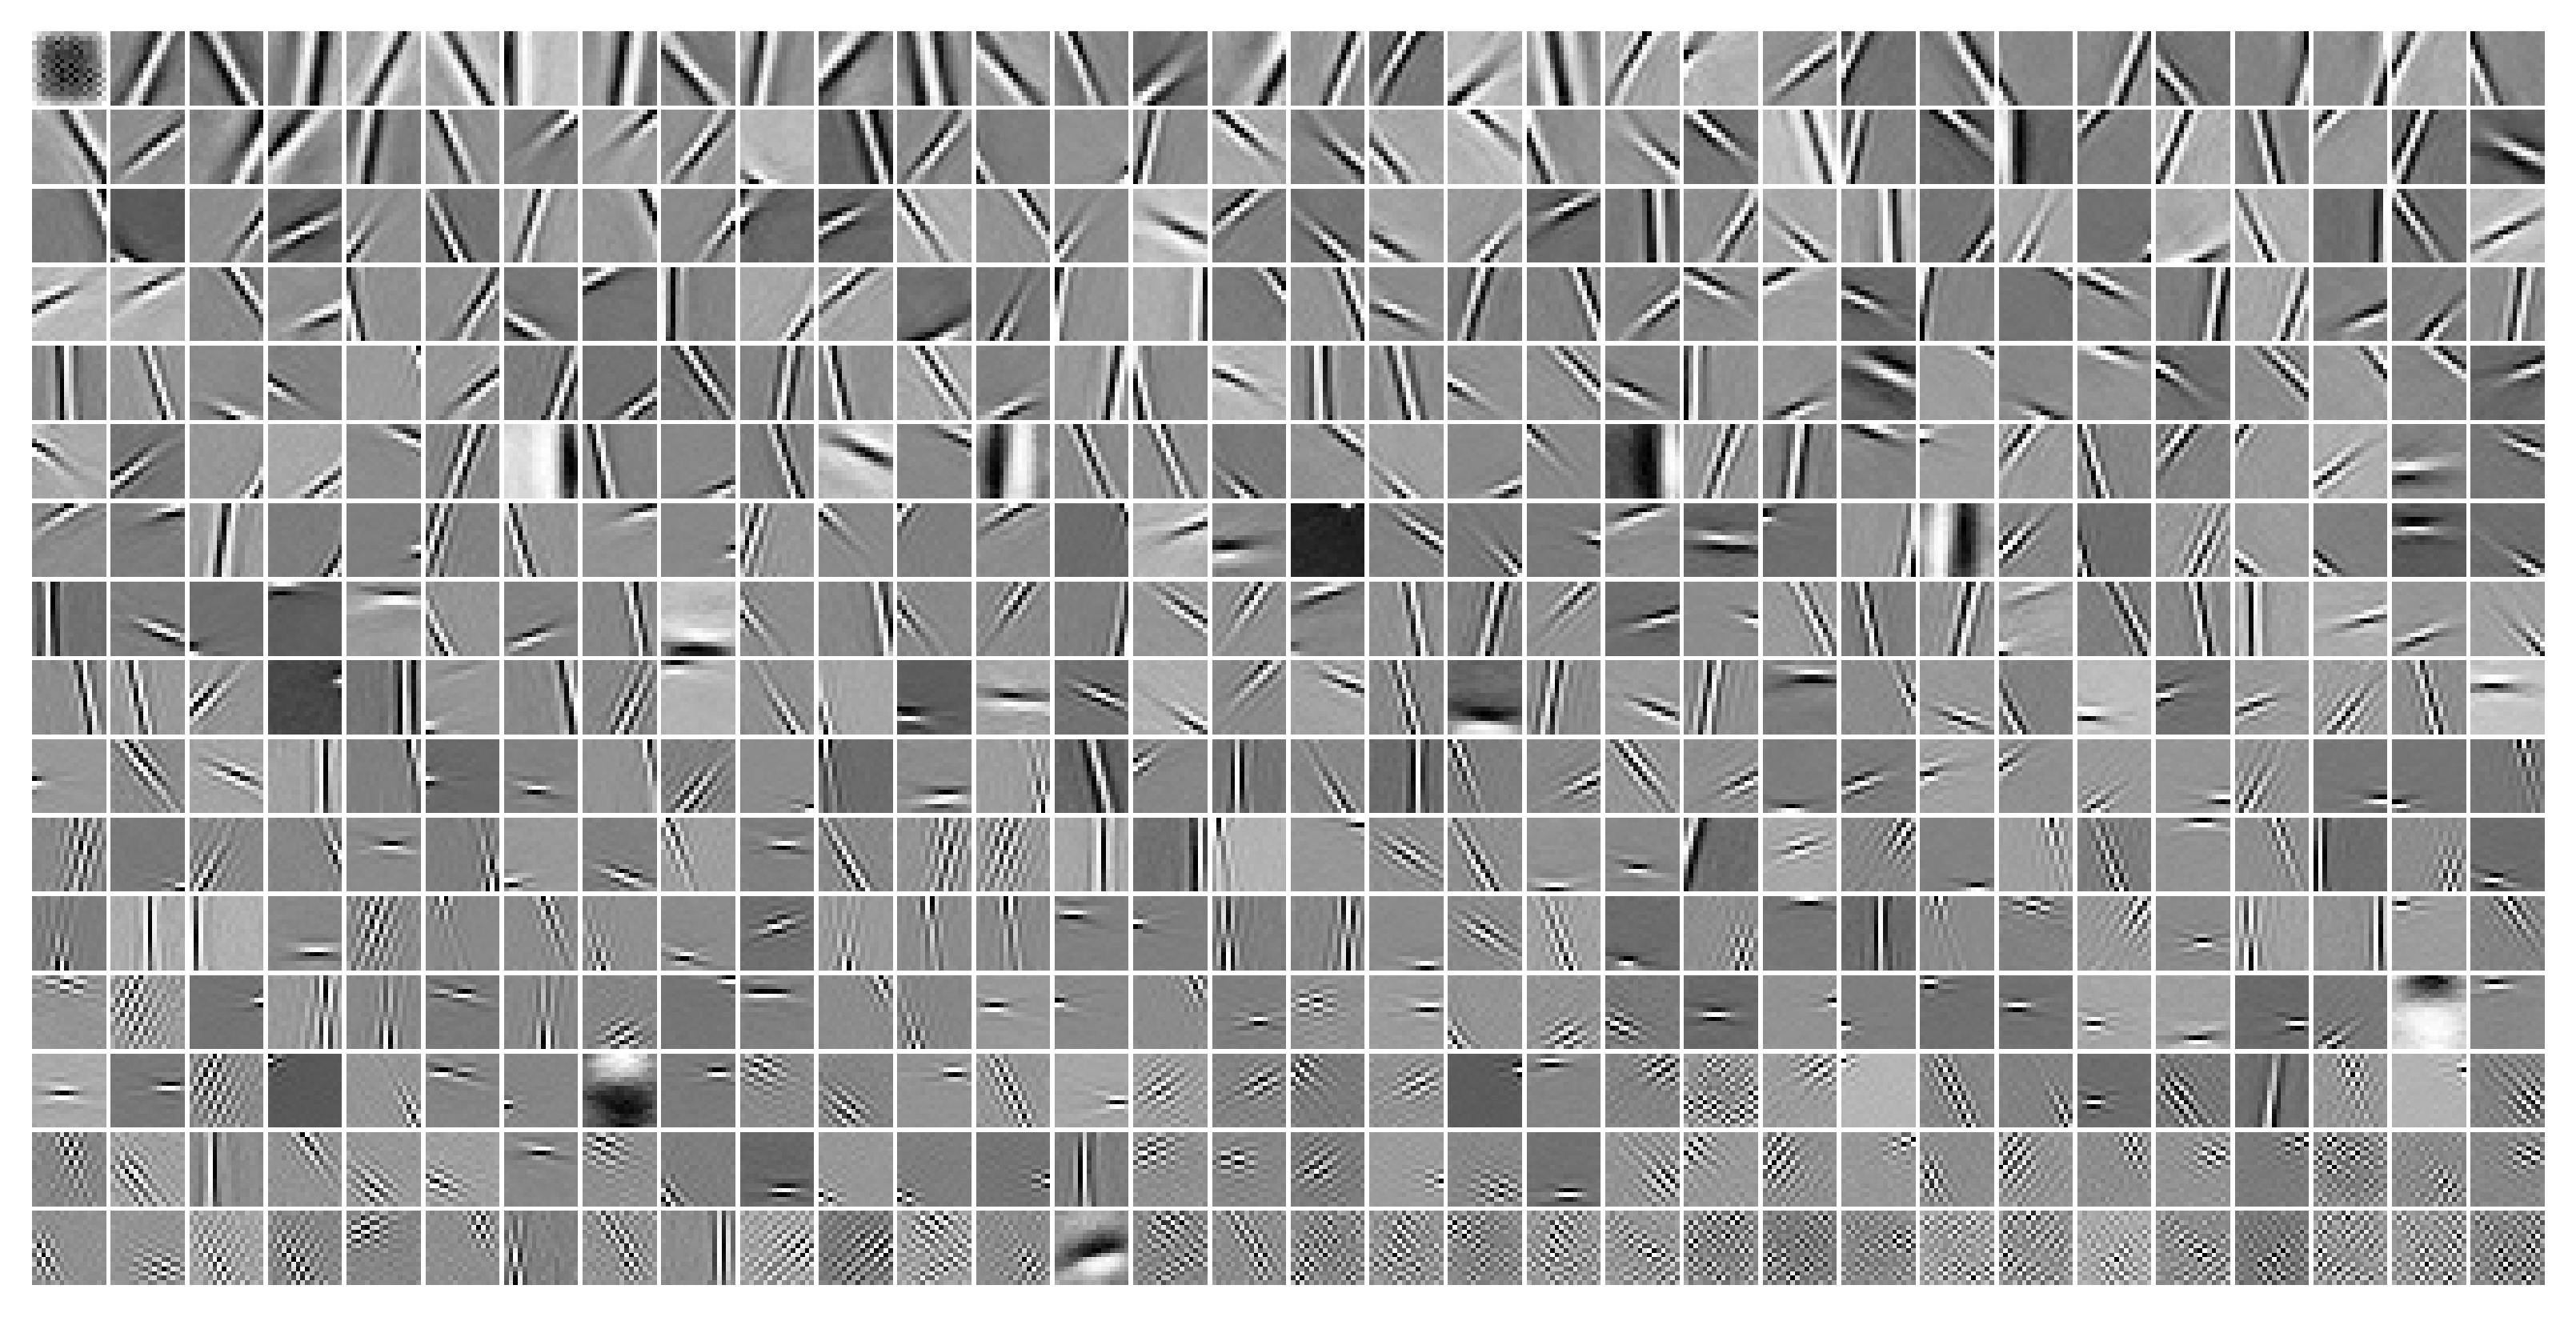

In [15]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))
tr.model.show(order=np.argsort(norms), dpi=400, pad=1);

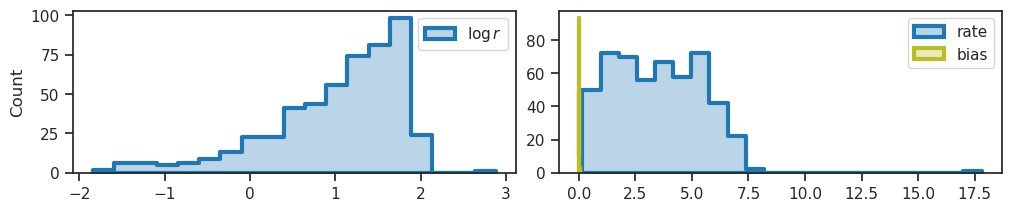

In [16]:
log_rate = tonp(tr.model.layer.u_init).ravel()
bias = tonp(tr.model.layer.log_bias.exp()).ravel()

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [17]:
dead = log_rate < -1
dead.sum(), (~dead).sum(), dead.sum() / len(dead)

(17, 495, 0.033203125)

In [18]:
(bias > 0).mean()

1.0

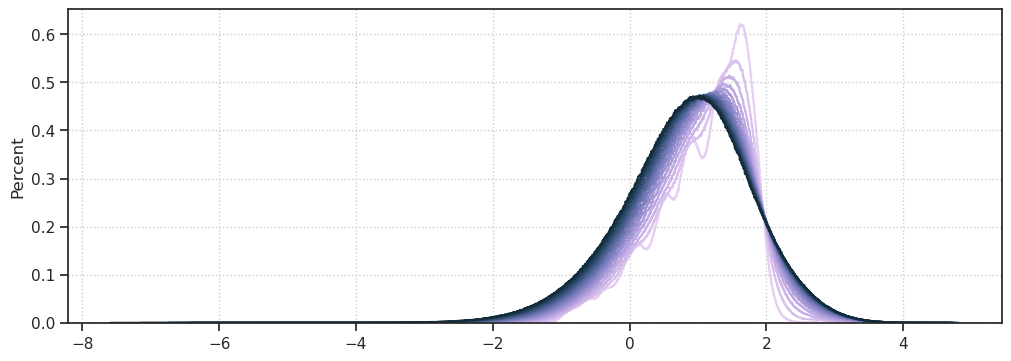

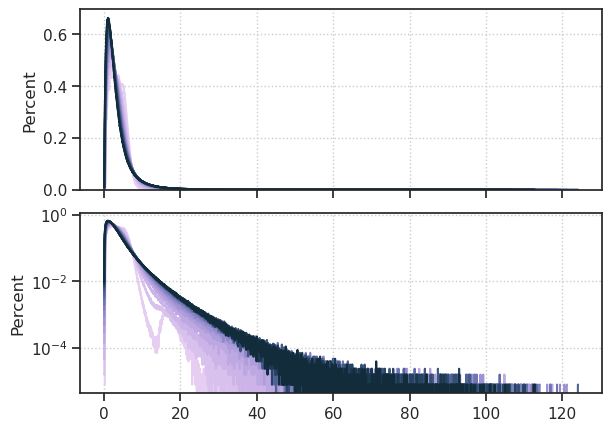

In [19]:
posterior_log_rates = collections.defaultdict(list)
for x, *_ in iter(tr.dl_vld):
    output = tr.model.xtract_ftr(x)
    for t, pois in output['posterior'].items():
        posterior_log_rates[t].append(torch.log(pois.rate))
posterior_log_rates = {
    t: tonp(torch.cat(v)) for t, v
    in posterior_log_rates.items()
}


fig, ax = create_figure(1, 1, (10, 3.5))
pal = get_cubehelix_palette(tr.model.cfg.t_train, start=2.5)

for i, (t, v) in enumerate(posterior_log_rates.items()):
    sns.histplot(
        v[:, ~dead].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
# ax.legend()
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (6, 4.2), sharex='col')
for i, (t, v) in enumerate(posterior_log_rates.items()):
    for ax in axes.flat:
        sns.histplot(
            np.exp(v[:, ~dead].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [20]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.8515783738056356, 0.7564048283277753, 0.9288121656434397],
 [0.8001162997533571, 0.7065759994349422, 0.9086196217899796],
 [0.7439792688412662, 0.6597624126404706, 0.8850042329763351],
 [0.6840855914209351, 0.6156494043651438, 0.8571492616027769],
 [0.621433610824204, 0.5738491579616475, 0.8244120665462615],
 [0.5570770035644698, 0.5339111022656235, 0.7863356920291484],
 [0.492099275511766, 0.4953333844045368, 0.7426568873299215],
 [0.4329197631622217, 0.4607041459016169, 0.6976371711644715],
 [0.36977282720352517, 0.4231998490866888, 0.6432078123635816],
 [0.3090934491249027, 0.3854178083786437, 0.5835384610223103],
 [0.2518347737894646, 0.34677973827838704, 0.5191313564287725],
 [0.1988566031415065, 0.30672139603456333, 0.45066798941042246],
 [0.1509035696744471, 0.2647062105047458, 0.3789955286940389],
 [0.10858527424075325, 0.22023851706947215, 0.30511000295886687],
 [0.07235872150128392, 0.17287618251766537, 0.23013648857700542]]

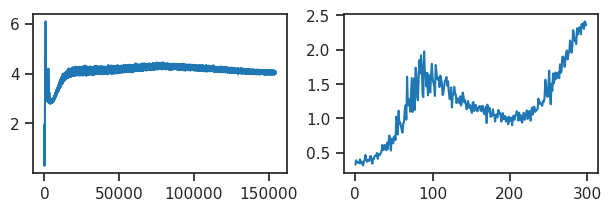

In [21]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300]);

In [22]:
(grad > 100).sum()

2

100%|███████████████████████████████| 130/130 [03:35<00:00,  1.66s/it]


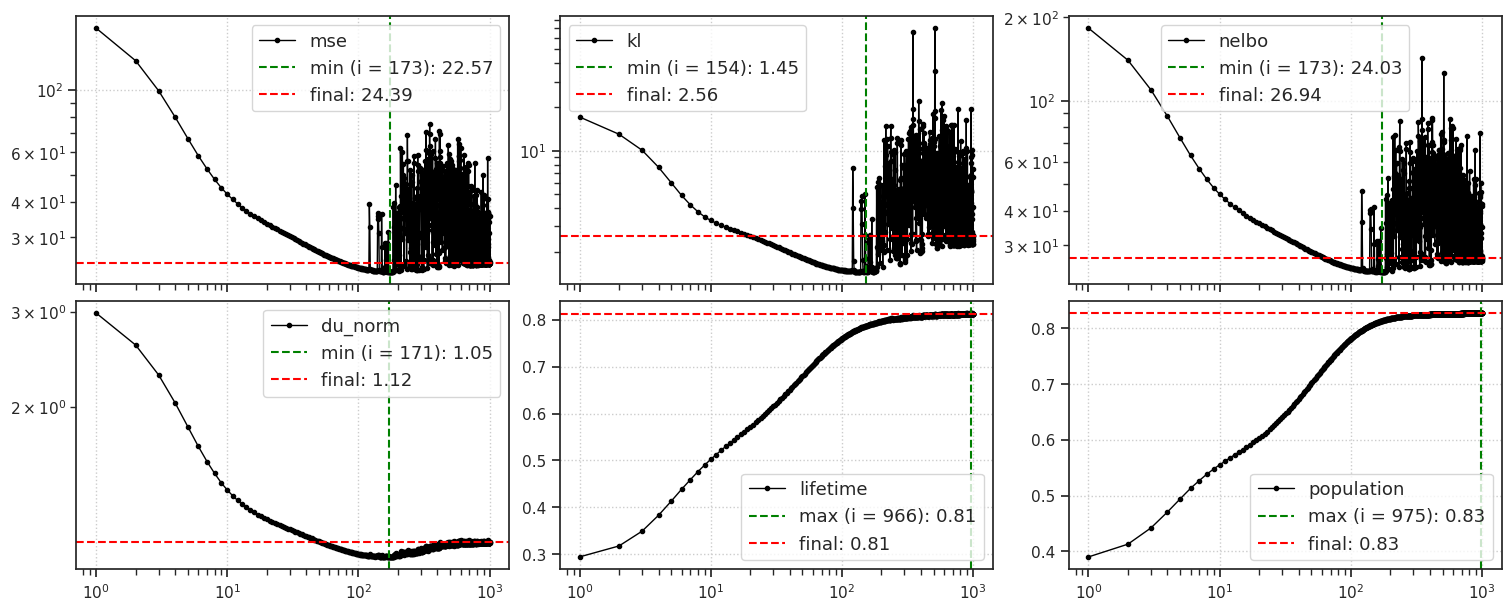

CPU times: user 4min 35s, sys: 11.7 s, total: 4min 46s
Wall time: 4min 46s


In [23]:
%%time

kws = dict(
    seq_total=1000,
    n_data_batches=None,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████| 130/130 [03:35<00:00,  1.66s/it]


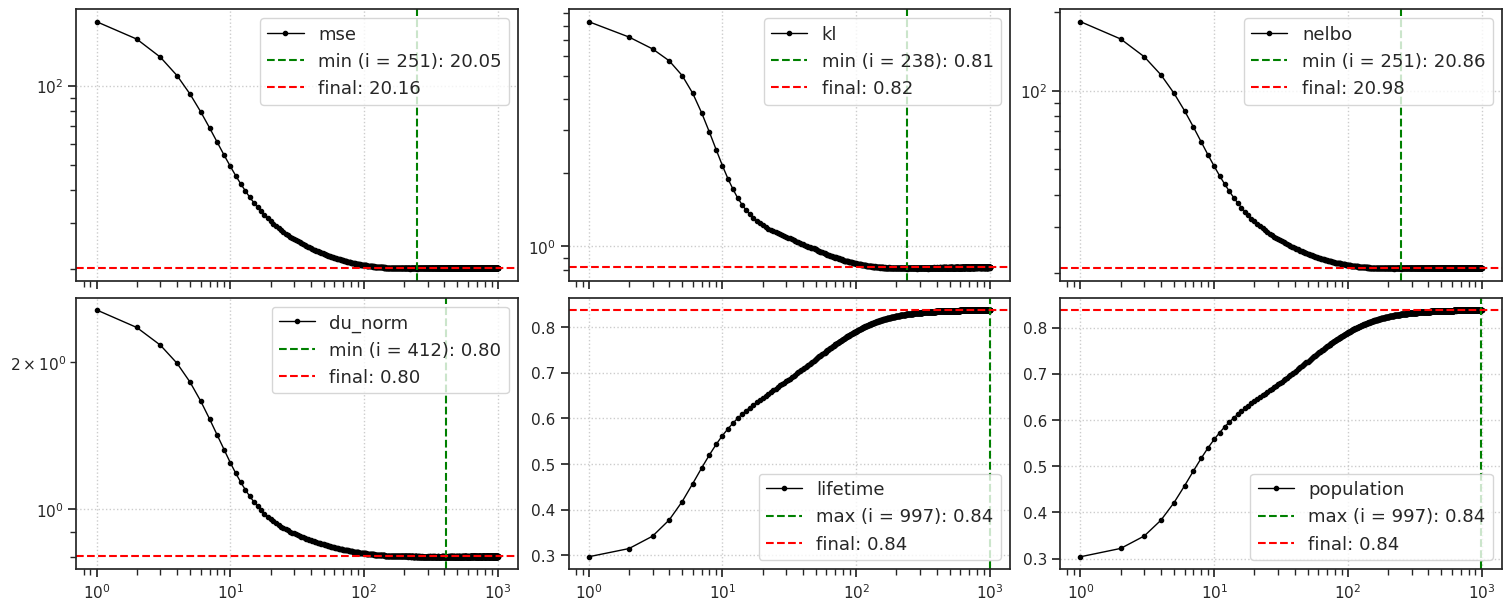

CPU times: user 4min 33s, sys: 13.7 s, total: 4min 46s
Wall time: 4min 46s


In [23]:
## Was: (16, 4.0)